# Campaign and training audit

We check which conditions were actually run and whether they can be compared. This notebook also works before the new campaign is downloaded.

## Introduction

The analysis supports the selection of heads for subsequent experiments. We keep prediction quality, reconstruction and geometry separate. Definitions and limitations are described in [METHODOLOGY.md](METHODOLOGY.md), and execution instructions in [README.md](README.md).

### Assumptions

The evaluated pixels come from the saved partitions of one campaign; the result does not measure transfer to a new patient or acquisition. A positive annotation is an observed P; a missing annotation does not confirm the absence of a molecule. The unit of model comparison is the seed, not the pixel; duplicate tasks for the same condition and seed do not increase the number of repetitions. Candidate selection uses validation, while test provides subsequent confirmation.

### Notation

$X \in \mathbb{R}^{N\times M}$ denotes TIC-normalized spectra, $\hat X$ reconstructions, $Y \in \{0,1\}^{N\times C}$ annotations, and $A$ label availability. $Z=\mathrm{Enc}(X)$ is the latent representation used by the head and decoder; $U=(Z-\beta)/\gamma$ reverses the affine transformation of the final LayerNorm. Evidence states follow N=0, P=1, U=2; **state U and representation $U$ are different objects**. $s$ denotes the positive ranking score. $r$ is an independent training repetition.


In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import display

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.visualization import predictive as plots

current = Path.cwd().resolve()
repository_root = next(path for path in (current, *current.parents) if (path / "pyproject.toml").is_file())
notebook_directory = repository_root / "assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded"
settings_path = Path(os.environ.get("MSI_PREDICTIVE_SETTINGS", notebook_directory / "analysis_settings.yaml"))
settings = campaign.load_settings(settings_path)
RESULTS = notebook_directory / "part_1_campaign_audit_results"
RESULTS.mkdir(parents=True, exist_ok=True)


2026-09-08 09:47:37,401 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-08 09:47:37,404 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-08 09:47:37,960 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-08 09:47:37,962 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-08 09:47:37,964 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-08 09:47:37,965 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


## Declared conditions and artifact coverage

### Methodology

#### Theoretical

Each unique architecture–loss pair is a condition. Identical YAML entries are not new interventions.

#### Implementation

Read YAML and manifests without loading weights. Check status, configuration, checkpoint, objective agreement, and identity of data, backbone and training. Missing sources remain in the table.

#### Figure descriptions

The tables show every grid entry, source and task. duplicate_of identifies the first equivalent entry; ready requires completed status, weights and a matching configuration.


In [2]:
grid = campaign.configured_grid(settings["experiment_config"])
models, sources = campaign.inventory(settings)
display(grid)
display(sources)
display(models)
reports.save_tables(RESULTS, configured_grid=grid, source_coverage=sources, inventory=models)
print("Declared tasks:", int(grid.repetitions.sum()), "Unique head conditions:", grid.condition.nunique())
coverage = campaign.coverage_table(grid, models)
display(coverage)
reports.save_tables(RESULTS, condition_coverage=coverage)

2026-09-08 09:47:45,449 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_campaign:250 | Audited 65 model manifests across 2 sources.


,grid_position,architecture,condition,label,head,family,weight_mode,head_weight,negative_weight,evidence,objective_json,duplicate_of,repetitions
0,0,conv1d-ae-32-16-8-latent-10,061bcbfb8c04,bce_global_positive_penalty (PositiveWeightedM...,molecule_binary,PositiveWeightedMultiLabelBCELoss,global_sqrt_negative_to_positive,0.2,0.0,{},"{""heads"": {""molecule_binary"": {""bce_global_pos...",NaN,5
1,1,conv1d-ae-32-16-8-latent-10,e27ded54dfca,bce_per_class_positive_penalty (PositiveWeight...,molecule_binary,PositiveWeightedMultiLabelBCELoss,per_class_sqrt_negative_to_positive,0.2,0.0,{},"{""heads"": {""molecule_binary"": {""bce_per_class_...",NaN,5
2,2,conv1d-ae-32-16-8-latent-10,a4c7ac80c5c1,pn_bce_unweighted (SignalMaskedBCELoss),molecule_binary,SignalMaskedBCELoss,none,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_binary"": {""pn_bce_unweigh...",NaN,5
3,3,conv1d-ae-32-16-8-latent-10,a4c7ac80c5c1,pn_bce_unweighted (SignalMaskedBCELoss),molecule_binary,SignalMaskedBCELoss,none,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_binary"": {""pn_bce_unweigh...",2.0,5
4,4,conv1d-ae-32-16-8-latent-10,40ee4c7e8820,pn_bce_global_positive_penalty (SignalMaskedBC...,molecule_binary,SignalMaskedBCELoss,global_sqrt_negative_to_positive,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_binary"": {""pn_bce_global_...",NaN,5
5,5,conv1d-ae-32-16-8-latent-10,40ee4c7e8820,pn_bce_global_positive_penalty (SignalMaskedBC...,molecule_binary,SignalMaskedBCELoss,global_sqrt_negative_to_positive,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_binary"": {""pn_bce_global_...",4.0,5
6,6,conv1d-ae-32-16-8-latent-10,d1f9a150e163,pn_bce_per_class_positive_penalty (SignalMaske...,molecule_binary,SignalMaskedBCELoss,per_class_sqrt_negative_to_positive,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_binary"": {""pn_bce_per_cla...",NaN,5
7,7,conv1d-ae-32-16-8-latent-10,d1f9a150e163,pn_bce_per_class_positive_penalty (SignalMaske...,molecule_binary,SignalMaskedBCELoss,per_class_sqrt_negative_to_positive,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_binary"": {""pn_bce_per_cla...",6.0,5
8,8,conv1d-ae-32-16-8-latent-10,20c052d026cd,pnu_ce (ThreeStateCrossEntropyLoss),molecule_pnu,ThreeStateCrossEntropyLoss,none,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_pnu"": {""pnu_ce"": {""params...",NaN,5
9,9,conv1d-ae-32-16-8-latent-10,20c052d026cd,pnu_ce (ThreeStateCrossEntropyLoss),molecule_pnu,ThreeStateCrossEntropyLoss,none,0.2,0.0,"{""absolute_threshold"": 0.0, ""bin_radius"": 1, ""...","{""heads"": {""molecule_pnu"": {""pnu_ce"": {""params...",8.0,5


,source,required,status_directory,available
0,predictive_initial,True,/home/max/repositories/MSIAutoEncoderWrapper/d...,True
1,historical_bce,True,/home/max/repositories/MSIAutoEncoderWrapper/d...,True


,source,role,model_id,task_id,grid_id,repetition,status,condition,label,head,...,artifact,weights_available,history_available,manifest,data_contract,backbone_contract,training_contract,config_matches_manifest,ready,duplicate_seed_condition
0,predictive_initial,candidate,predictive_initial/task_000000,task_000000,grid_0000,0,completed,061bcbfb8c04,bce_global_positive_penalty (PositiveWeightedM...,molecule_binary,...,/home/max/repositories/MSIAutoEncoderWrapper/d...,True,True,/home/max/repositories/MSIAutoEncoderWrapper/d...,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,True,True,False
1,predictive_initial,candidate,predictive_initial/task_000001,task_000001,grid_0000,1,completed,061bcbfb8c04,bce_global_positive_penalty (PositiveWeightedM...,molecule_binary,...,/home/max/repositories/MSIAutoEncoderWrapper/d...,True,True,/home/max/repositories/MSIAutoEncoderWrapper/d...,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,True,True,False
2,predictive_initial,candidate,predictive_initial/task_000002,task_000002,grid_0000,2,completed,061bcbfb8c04,bce_global_positive_penalty (PositiveWeightedM...,molecule_binary,...,/home/max/repositories/MSIAutoEncoderWrapper/d...,True,True,/home/max/repositories/MSIAutoEncoderWrapper/d...,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,True,True,False
3,predictive_initial,candidate,predictive_initial/task_000003,task_000003,grid_0000,3,completed,061bcbfb8c04,bce_global_positive_penalty (PositiveWeightedM...,molecule_binary,...,/home/max/repositories/MSIAutoEncoderWrapper/d...,True,True,/home/max/repositories/MSIAutoEncoderWrapper/d...,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,True,True,False
4,predictive_initial,candidate,predictive_initial/task_000004,task_000004,grid_0000,4,completed,061bcbfb8c04,bce_global_positive_penalty (PositiveWeightedM...,molecule_binary,...,/home/max/repositories/MSIAutoEncoderWrapper/d...,True,True,/home/max/repositories/MSIAutoEncoderWrapper/d...,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,historical_bce,baseline,historical_bce/task_000000,task_000000,grid_0000,0,completed,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),molecule_primary,...,/home/max/repositories/MSIAutoEncoderWrapper/d...,True,True,/home/max/repositories/MSIAutoEncoderWrapper/d...,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,True,True,False
61,historical_bce,baseline,historical_bce/task_000001,task_000001,grid_0000,1,completed,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),molecule_primary,...,/home/max/repositories/MSIAutoEncoderWrapper/d...,True,True,/home/max/repositories/MSIAutoEncoderWrapper/d...,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,True,True,False
62,historical_bce,baseline,historical_bce/task_000002,task_000002,grid_0000,2,completed,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),molecule_primary,...,/home/max/repositories/MSIAutoEncoderWrapper/d...,True,True,/home/max/repositories/MSIAutoEncoderWrapper/d...,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,True,True,False
63,historical_bce,baseline,historical_bce/task_000003,task_000003

2026-09-08 09:47:45,492 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 3 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_1_campaign_audit_results.


Declared tasks: 60 Unique head conditions: 8


,condition,label,declared_cells,expected_tasks,expected_seeds,downloaded_tasks,ready_tasks,ready_seeds,complete_seed_coverage
0,061bcbfb8c04,bce_global_positive_penalty (PositiveWeightedM...,1,5,5,5,5,5,True
1,20c052d026cd,pnu_ce (ThreeStateCrossEntropyLoss),2,10,5,10,10,5,True
2,32e2c5ffe6e2,pu_ranking (SymmetricPURankingLoss),1,5,5,5,5,5,True
3,40ee4c7e8820,pn_bce_global_positive_penalty (SignalMaskedBC...,2,10,5,10,10,5,True
4,a4c7ac80c5c1,pn_bce_unweighted (SignalMaskedBCELoss),2,10,5,10,10,5,True
5,c37325811656,vpu (VariationalPULoss),1,5,5,5,5,5,True
6,d1f9a150e163,pn_bce_per_class_positive_penalty (SignalMaske...,2,10,5,10,10,5,True
7,e27ded54dfca,bce_per_class_positive_penalty (PositiveWeight...,1,5,5,5,5,5,True


2026-09-08 09:47:45,521 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 1 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_1_campaign_audit_results.


### Remarks

Results have not yet been computed for the target campaign.

### Notes


## Training dynamics and checkpoint checks

### Methodology

#### Theoretical

Curves help detect instability and undertraining. Total costs from different objectives have different meanings and scales; their levels are not interpreted as a ranking of heads.

#### Implementation

Epoch entries require metrics.epoch. Final evaluations without an epoch remain separate records. Every metric, is_best flag and phase is retained; the final epoch is not equated with the saved best weights.

#### Figure descriptions

x-axis: epoch; y-axis: the selected metric recorded in the history. Each translucent line is a task; colour identifies the head. Select a common reconstruction component when comparing levels.


,model_id,label,phase,epoch,record_type,split,metric,value,is_best
0,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,joint_predictive,1.0,epoch,,epoch,1.000000,True
1,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,joint_predictive,1.0,epoch,,duration,32.001061,True
2,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,joint_predictive,1.0,epoch,,masserstein,13.838369,True
3,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,joint_predictive,1.0,epoch,,molecule_binary__bce_global_positive_penalty,0.217497,True
4,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,joint_predictive,1.0,epoch,,total_loss,13.881869,True
...,...,...,...,...,...,...,...,...,...
8965,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),joint_predictive,15.0,epoch,,validation_total_loss,4.103799,False
8966,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),joint_predictive,15.0,epoch,,best_loss,3.491158,False
8967,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),joint_predictive,NaN,evaluation,test,masserstein,3.494184,False
8968,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),joint_predictive,NaN,evaluation,test,molecule_primary__balanced_bce,0.033273,False


2026-09-08 09:47:45,631 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 1 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_1_campaign_audit_results.


,metric,record_type
0,epoch,epoch
1,duration,epoch
2,masserstein,epoch
3,molecule_binary__bce_global_positive_penalty,epoch
4,total_loss,epoch
5,validation_masserstein,epoch
6,validation_molecule_binary__bce_global_positiv...,epoch
7,validation_total_loss,epoch
8,best_loss,epoch
135,masserstein,evaluation


,source,role,condition,label,repetition,initialization_seed,training_seed,data_contract,backbone_contract,training_contract,phase,epoch,metric,value,task_count,duplicate_min,duplicate_max,duplicate_range
1482,predictive_initial,candidate,20c052d026cd,pnu_ce (ThreeStateCrossEntropyLoss),0,91154199,32238397,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,joint_predictive,15.0,validation_masserstein,3.682186,2,3.328277,4.036094,0.707817
1617,predictive_initial,candidate,20c052d026cd,pnu_ce (ThreeStateCrossEntropyLoss),1,919377028,892754137,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,joint_predictive,15.0,validation_masserstein,3.498636,2,3.373697,3.623575,0.249877
1752,predictive_initial,candidate,20c052d026cd,pnu_ce (ThreeStateCrossEntropyLoss),2,2136253289,442265914,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,joint_predictive,15.0,validation_masserstein,4.007045,2,3.861716,4.152374,0.290658
1887,predictive_initial,candidate,20c052d026cd,pnu_ce (ThreeStateCrossEntropyLoss),3,276187349,194761695,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,joint_predictive,15.0,validation_masserstein,3.442974,2,3.406937,3.479012,0.072075
2022,predictive_initial,candidate,20c052d026cd,pnu_ce (ThreeStateCrossEntropyLoss),4,1915557887,1927548799,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,joint_predictive,15.0,validation_masserstein,4.803623,2,3.726081,5.881165,2.155084
2832,predictive_initial,candidate,40ee4c7e8820,pn_bce_global_positive_penalty (SignalMaskedBC...,0,91154199,32238397,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,joint_predictive,15.0,validation_masserstein,3.585570,2,3.422577,3.748563,0.325986
2967,predictive_initial,candidate,40ee4c7e8820,pn_bce_global_positive_penalty (SignalMaskedBC...,1,919377028,892754137,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,joint_predictive,15.0,validation_masserstein,3.674348,2,3.614528,3.734169,0.119641
3102,predictive_initial,candidate,40ee4c7e8820,pn_bce_global_positive_penalty (SignalMaskedBC...,2,2136253289,442265914,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,joint_predictive,15.0,validation_masserstein,3.268233,2,3.160024,3.376441,0.216417
3237,predictive_initial,candidate,40ee4c7e8820,pn_bce_global_positive_penalty (SignalMaskedBC...,3,276187349,194761695,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,joint_predictive,15.0,validation_masserstein,3.582195,2,3.349401,3.814990,0.465589
3372,predictive_initial,candidate,40ee4c7e8820,pn_bce_global_positive_penalty (SignalMaskedBC...,4,1915557887,1927548799,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,joint_predictive,15.0,validation_masserstein,3.741301,2,3.650307,3.832295,0.181988


2026-09-08 09:47:47,260 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 2 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_1_campaign_audit_results.


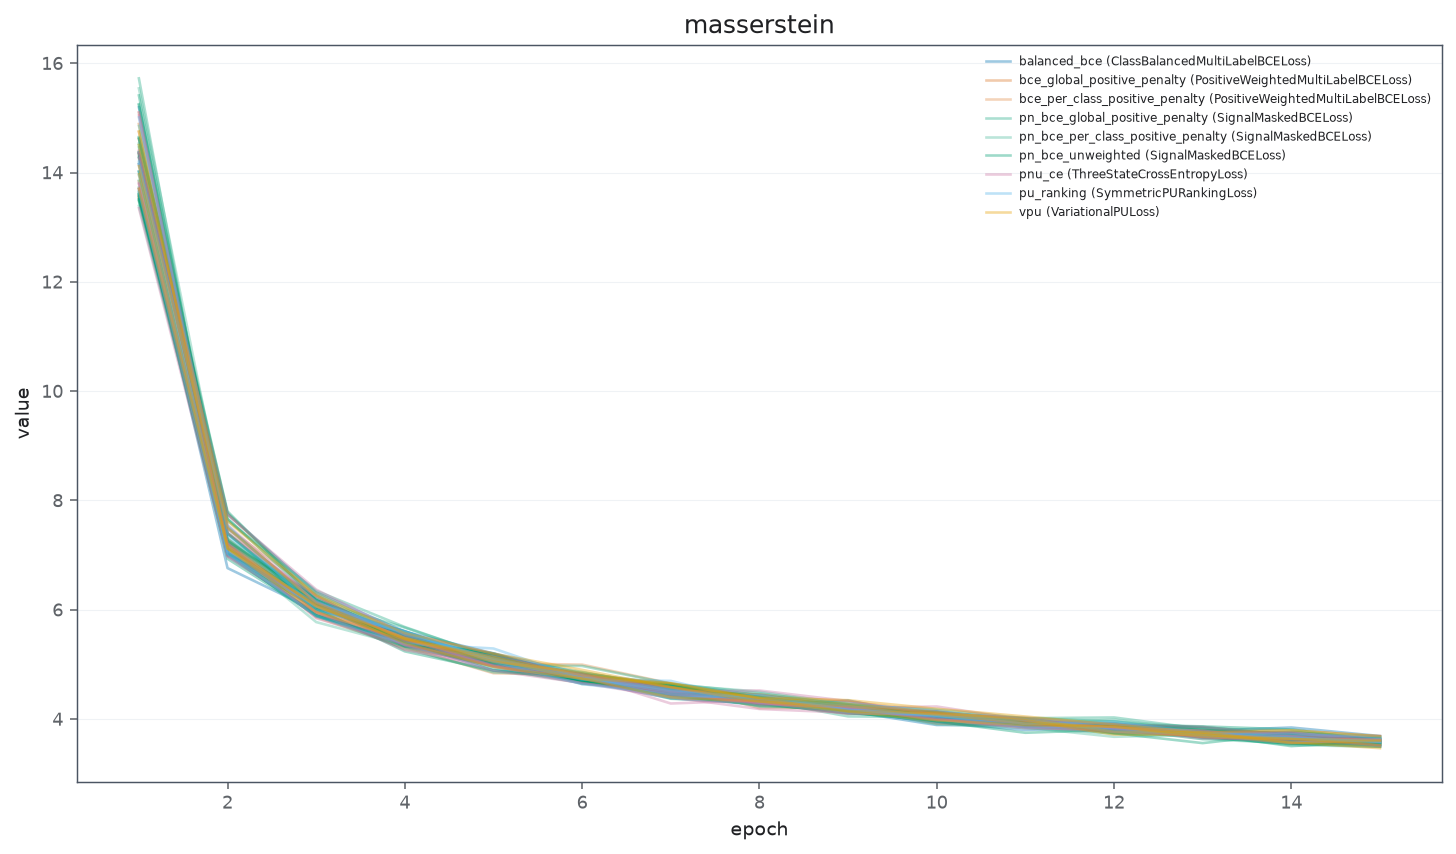

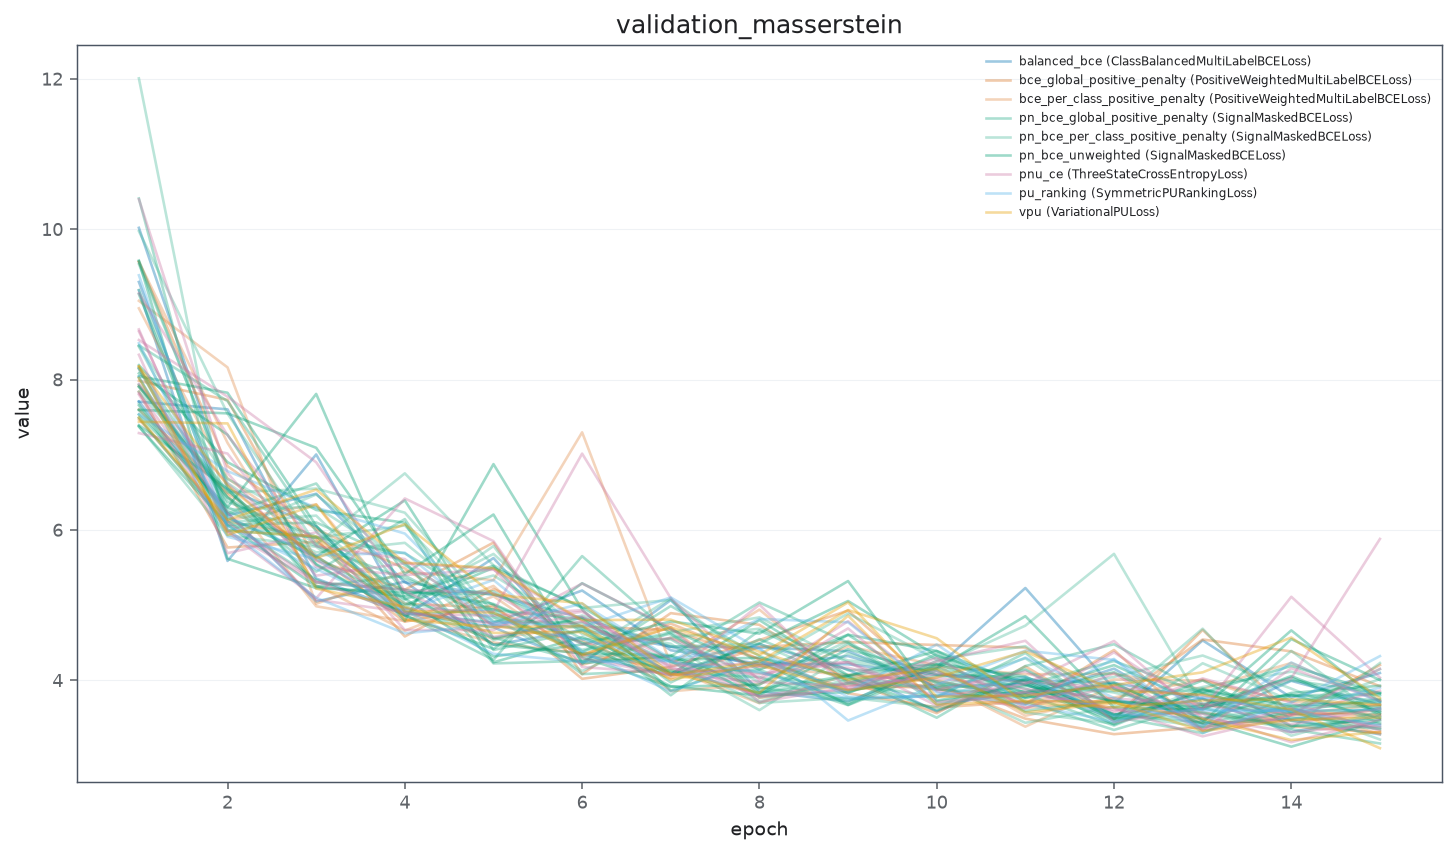

In [3]:
history = campaign.training_history(models)
display(history)
reports.save_tables(RESULTS, training_history=history)
if not history.empty:
    display(history[["metric", "record_type"]].drop_duplicates())
    reconstruction_metrics = history.loc[history.metric.str.contains("masserstein", case=False), "metric"].unique()
    for metric in reconstruction_metrics:
        frame = history[(history.record_type == "epoch") & (history.metric == metric)]
        plots.trajectories(frame, x="epoch", title=metric).savefig(RESULTS / f"history_{metric}.png")
if not history.empty:
    history_units = reports.experimental_units(history.query("record_type == 'epoch'").merge(models[["model_id", "condition"]], on="model_id", validate="many_to_one"), models, ["phase", "epoch", "metric"])
    duplicate_history = history_units.query("task_count > 1").copy()
    duplicate_history["duplicate_range"] = duplicate_history.duplicate_max - duplicate_history.duplicate_min
    display(duplicate_history.query("metric == 'validation_masserstein' and epoch == 15"))
    reports.save_tables(RESULTS, history_experimental_units=history_units, duplicate_history=duplicate_history)


### Remarks

Results have not yet been computed for the target campaign.

### Notes


## Results / Summary

### LLM

An executable protocol and table exports have been prepared. Results from the target campaign are not yet available; this file does not contain an empirical conclusion that any head is superior. After execution, assess effect direction and magnitude, variation across seeds, completeness of pairs and limitations of the label definitions.

### Person
